# Cloud radiative cases A–F in ERA5, by surface class

Applies Rachel Gillespie's `identify_radiative_cases.py` phase-structure
detection to ERA5 pressure-level profiles, split by the same five surface
classes used elsewhere plus the single grid cell holding the DOE ARM facility
at Utqiaġvik.

The detection logic is a **verified port**: the vectorised implementation in
`cloud_vertical_cases.py` was checked against Rachel's scalar `detect_column`
on 100,000 random profiles plus one hand-built example of each case — zero
disagreements. What changes is not the logic but the inputs.

## Four differences you have to keep in mind

**1 — Phase is derived from water content, not retrieved.** ARM assigns a
discrete phase per range gate. ERA5 gives continuous LWC and IWC, so phase comes
from a threshold: clear if both are below it, liquid / ice if one is above,
mixed if both are. The threshold is on **density (g m⁻³)** rather than layer
mass path, because density is what a radar range gate responds to and it does
not change with layer thickness.

**2 — Fractions are mass-weighted, not level counts.** Rachel's purity rule allows a
contaminating phase to be ≤10% of the cloud's pixels — fine across ~500 ARM
range gates. ERA5 has 23 levels and a typical cloud occupies 3–8 of them, so
10% of 8 rounds down to **zero**. On level counts the rule stops meaning "mostly
one phase" and silently becomes "no trace of any other phase", which almost no
real profile satisfies. The default basis is therefore mass:
`frac_ice = IWP / (LWP + IWP)`. Pass `basis="levels"` to see the degeneracy.

**3 — No temporal post-processing, so compare against the right column.**
Rachel bridges gaps ≤90 s and drops events shorter than 30 min, both defined on
a 30-second grid. ERA5 is hourly — one sample already exceeds her 30-minute
minimum. Neither step can be applied, so these numbers are the equivalent of
her **"Hours passing column filters"** column. They are *not* comparable to her
"Hours in periods ≥ 30 min" column.

**4 — One filter is vacuous in both codes.** "Clear sky below cloud base" is
`all(phase[:cloud_base] == CLEAR)` where `cloud_base` is the first non-clear
index — true by construction, rejecting nothing. Kept for faithfulness and
reported, so the agreement is visible rather than assumed.

## Setup

In [8]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt

import plot_cloud_cases_by_surface as ccs

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110

SAVE_DIR = None
# SAVE_DIR = Path("figures/CloudCases")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load and classify

The slow cell: it streams every pressure-level file, derives the phase profile,
runs the case detection, and accumulates area-weighted counts by surface class.

Options — `region`, `storage`, `basis` (`"mass"` or `"levels"`),
`phase_threshold` (g m⁻³), `min_cloud_fraction`, the siconc/lsm class bounds,
and `mask_grid`.

**Speed.** Two things make this fast enough to re-run. Only the single-level
files whose days the pressure archive actually covers are opened — for a
four-month archive that is 26 files of 654, and skipping the rest is worth more
than everything else combined. Then the per-file classification runs across
`jobs` worker processes (`0` = one per core).

Files are independent and every reduction is a sum, so the answer does not
depend on the worker count: verified against a frozen file list, serial and
parallel agree to **4e-14** on the case percentages, which is float round-off.
If the pool cannot start — spawn needs an importable `__main__`, which a
`python -c` does not have — it falls back to serial automatically rather than
failing.

In [9]:
A = ccs.prepare(
    region="barrow",
    storage="local",
    basis="mass",              # "levels" reproduces the literal ARM arithmetic
    phase_threshold=1e-3,      # g m-3; see the threshold note below
    phase_rule="fraction",     # recommended; "absolute" for the old behaviour
    min_cloud_fraction=0.99,
    jobs=0,                    # 0 = one worker per CPU core
)

Cloud cases A-F by surface class
  Pressure   : 116 file(s) from /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow_pressure
  Single lvl : 654 file(s)
  Basis      : mass-weighted phase fractions
  Phase thr  : 0.001 g m-3   rule: fraction
  Cloudy when: tcc >= 0.99
  Loaded single-level subset: 4,752 time steps


  !! era5_pl_barrow_202508_01-02.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_03-04.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_05-06.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_07-08.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_09-10.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_11-12.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_13-14.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_15-16.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_17-18.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_19-20.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_21-22.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_23-24.nc: no single-level data for these times; s

    [20/116] era5_pl_barrow_202509_07-08.nc
    [30/116] era5_pl_barrow_202509_27-28.nc
    [40/116] era5_pl_barrow_202510_15-16.nc
    [50/116] era5_pl_barrow_202511_05-06.nc
    [60/116] era5_pl_barrow_202511_25-26.nc
    [70/116] era5_pl_barrow_202512_13-14.nc
    [80/116] era5_pl_barrow_202601_01-02.nc
    [90/116] era5_pl_barrow_202601_21-22.nc
    [100/116] era5_pl_barrow_202602_11-12.nc
    [110/116] era5_pl_barrow_202603_03-04.nc
    [116/116] era5_pl_barrow_202603_15-16.nc


## Filter breakdown and case frequencies

Read the filter table first — in this dataset one filter dominates everything
downstream, and the case frequencies cannot be interpreted without it.

In [10]:
ccs.print_report(A)


------------------------------------------------------------------------------
  FILTER BREAKDOWN (fraction of all cell-hours, each filter alone)
------------------------------------------------------------------------------
    Total cloud cover >= threshold        61.6%
    Has liquid in the column              38.4%
    Clear sky below cloud base           100.0%   (vacuous by construction)
    No drizzle/rain in column             98.1%
    No snow in column                     41.2%
    Precipitation < 0.01 mm/hr            57.8%
    LWP > 2 g/m2                          53.0%

------------------------------------------------------------------------------
  CASE FREQUENCY, whole domain
------------------------------------------------------------------------------
    case  description                                          % of cell-hours
    A     Pure liquid  (single layer)                                   1.501%
    B     Liquid-topped MPC: liquid -> mixed  (single layer)  

## Figures

### 1. Case frequency by surface class

Each case as a percent of that class's cell-hours. The ARM cell is the black
bar; it classifies as coastal, so the coastal bar is the natural comparison.

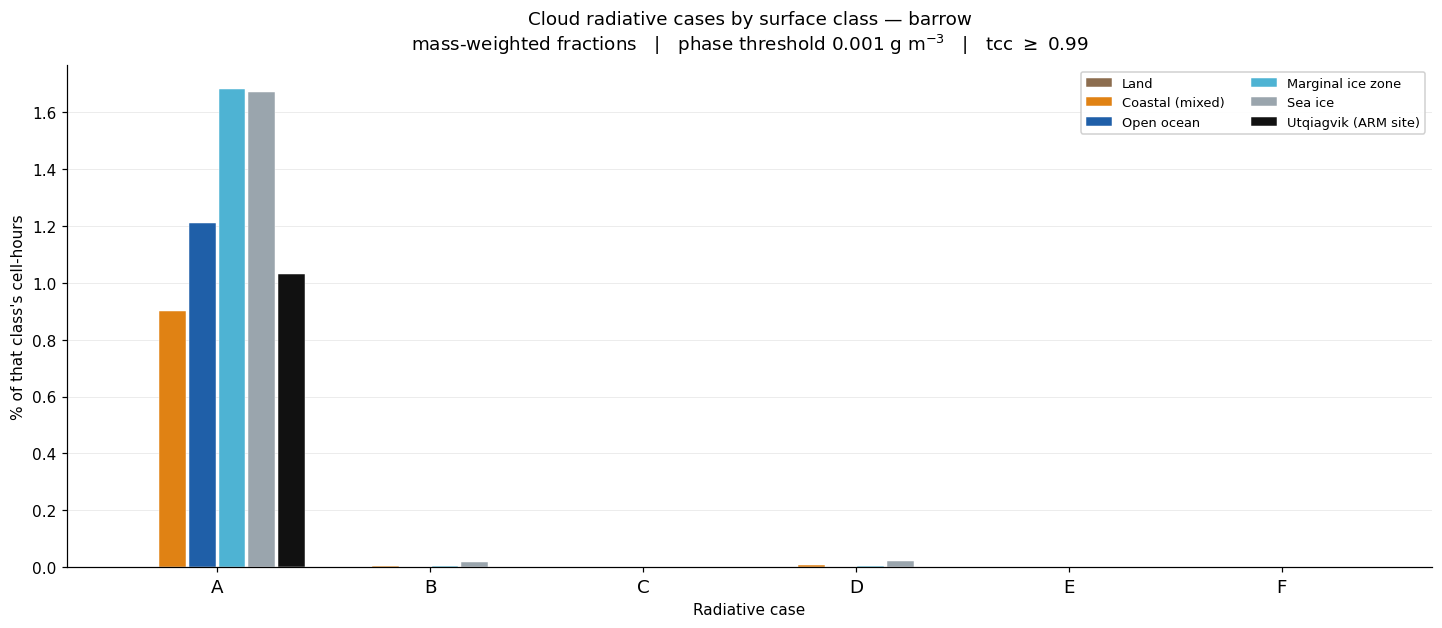

In [11]:
ccs.fig_case_by_surface(A, out_dir=SAVE_DIR);

### 2. Case frequency by month

Domain against the ARM cell, one panel per case.

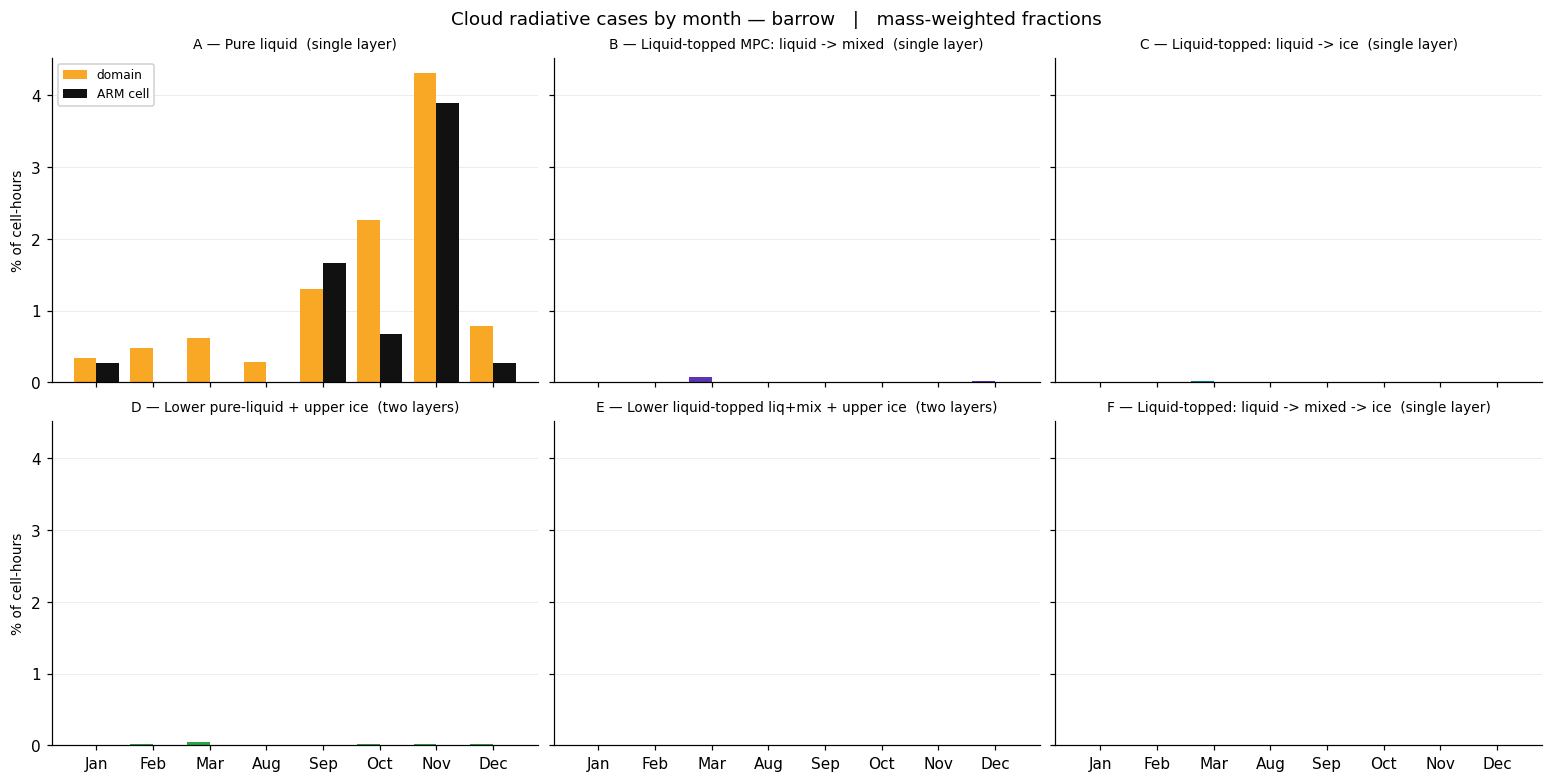

In [12]:
ccs.fig_case_monthly(A, out_dir=SAVE_DIR);

### 3. Quality filters

Each filter's pass rate **on its own**, not cumulatively. The grey bar is the
vacuous one.

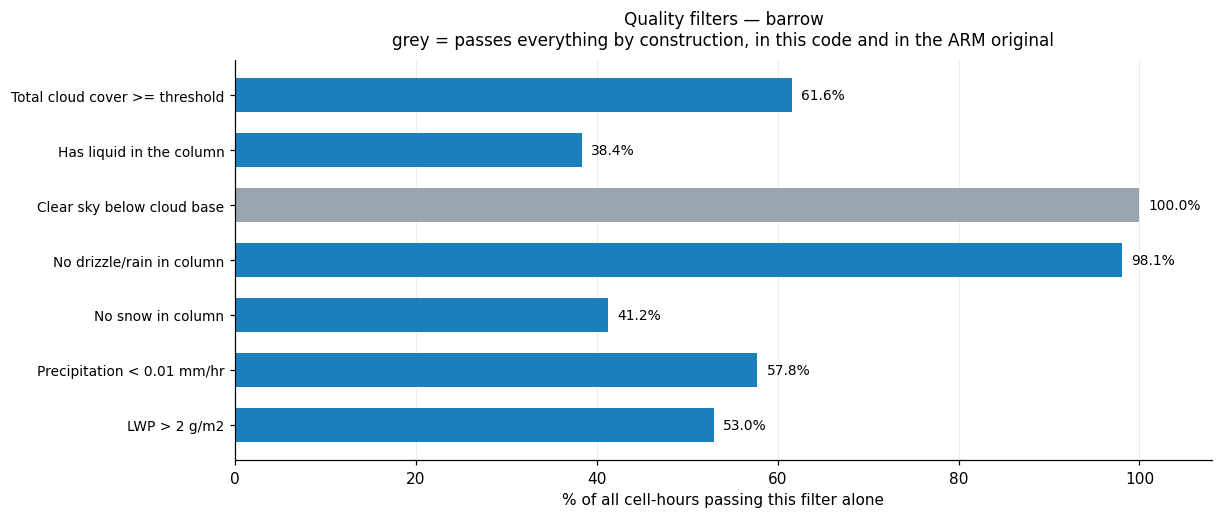

In [13]:
ccs.fig_filter_breakdown(A, out_dir=SAVE_DIR);

## Choosing the phase threshold, and the rule it feeds

### What ERA5 can actually store

Measured on this archive, the smallest non-zero specific contents are

| | floor (kg/kg) | as density at ρ = 1.35 |
|---|---|---|
| `clwc` | 2⁻²² = 2.384e-07 | **3.2e-04 g m⁻³** |
| `ciwc` | 2⁻²⁶ = 1.490e-08 | 2.0e-05 g m⁻³ |

**The two are not the same — ERA5 stores ice 16× finer than liquid.** That has a
direct consequence: any threshold below about 3e-4 g m⁻³ sits *inside* the
liquid floor, so it would keep every non-zero liquid value while still cutting
ice — biasing the phase balance by construction rather than by physics.

The default 1e-3 g m⁻³ sits ~3× above the liquid floor and keeps a near-identical
share of each species (66.3% of non-zero LWC, 68.1% of IWC), so it discriminates
on physics. A radar-like 5e-3–1e-2 is also defensible; **below 5e-4 is not**.

One thing this rules out: the 30:1 imbalance between ice-only and liquid-only
levels is *not* a threshold artefact, since the cut is nearly symmetric. It is
ERA5 telling you that ice occupies far more of the column than liquid does.

### Two rules for assigning a level's phase

`"absolute"` tests each species against the threshold **independently**, so a
level is mixed whenever both clear the floor — no matter how lopsided. That is
inconsistent with the column purity test, which is fractional, and the two
interact badly: a level 99% liquid by mass gets labelled mixed, and its *entire*
condensate then counts toward `frac_mix`. On this archive 15.9% of levels
labelled mixed are more than 90% liquid.

`"fraction"` (default) lets the threshold decide only whether there is cloud at
all, and hands the phase to the same 90/10 rule used at column level:
liquid below 10% ice mass share, ice above 90%, mixed in between.

### Side by side

In [14]:
import numpy as np
import xarray as xr, glob
from cloud_vertical_cases import (profile_fields, detect_columns, CLEAR,
                                  LIQUID, ICE, MIXED, CASE_LABELS, CASE_ORDER)

files = sorted(glob.glob("data/barrow_pressure/*.nc"))[-14:]   # a recent sample
out = {}
for rule in ("absolute", "fraction"):
    lab = {CLEAR: 0, LIQUID: 0, ICE: 0, MIXED: 0}
    tot = 0; cases = np.zeros(7); ncol = 0
    for f in files:
        pl = xr.open_dataset(f).load()
        sp = np.full((pl.sizes["valid_time"], pl.sizes["latitude"],
                      pl.sizes["longitude"]), 101325.0)   # only the bottom layer
        ph, lwp, iwp, _ = profile_fields(pl, sp, 1e-3, rule)
        for k in lab:
            lab[k] += int((ph == k).sum())
        tot += ph.size
        r = detect_columns(ph.reshape(-1, ph.shape[-1]),
                           lwp.reshape(-1, lwp.shape[-1]),
                           iwp.reshape(-1, iwp.shape[-1]), basis="mass")
        for c in range(7):
            cases[c] += int((r["case"] == c).sum())
        ncol += r["case"].size
        pl.close()
    out[rule] = (lab, tot, cases, ncol)

print("PER-LEVEL PHASE LABELS  [% of all levels]")
print(f"  {'':<14}{'absolute':>12}{'fraction':>12}{'change':>11}")
for k, n in ((CLEAR, "clear"), (LIQUID, "liquid only"),
             (ICE, "ice only"), (MIXED, "mixed")):
    a = 100 * out["absolute"][0][k] / out["absolute"][1]
    b = 100 * out["fraction"][0][k] / out["fraction"][1]
    print(f"  {n:<14}{a:>11.2f}%{b:>11.2f}%{b - a:>+10.2f}")

print("\nCASE FREQUENCY  [% of columns, phase structure only,")
print("                 before the quality filters]")
print(f"  {'case':<6}{'absolute':>12}{'fraction':>12}{'change':>11}")
for c in CASE_ORDER:
    a = 100 * out["absolute"][2][c] / out["absolute"][3]
    b = 100 * out["fraction"][2][c] / out["fraction"][3]
    print(f"  {CASE_LABELS[c]:<6}{a:>11.3f}%{b:>11.3f}%{b - a:>+10.3f}")
ta = 100 * out["absolute"][2][CASE_ORDER].sum() / out["absolute"][3]
tb = 100 * out["fraction"][2][CASE_ORDER].sum() / out["fraction"][3]
print(f"  {'total':<6}{ta:>11.3f}%{tb:>11.3f}%{tb - ta:>+10.3f}")
print(f"\n  ratio fraction/absolute = {tb / ta:.2f}x")

PER-LEVEL PHASE LABELS  [% of all levels]
                    absolute    fraction     change
  clear               74.52%      74.37%     -0.14
  liquid only          0.49%       0.86%     +0.37
  ice only            21.12%      20.89%     -0.23
  mixed                3.87%       3.88%     +0.01

CASE FREQUENCY  [% of columns, phase structure only,
                 before the quality filters]
  case      absolute    fraction     change
  A           0.619%      1.695%    +1.076
  B           0.040%      0.118%    +0.078
  C           0.031%      0.040%    +0.008
  D           0.115%      0.108%    -0.007
  E           0.001%      0.000%    -0.000
  F           0.002%      0.005%    +0.002
  total       0.808%      1.966%    +1.158

  ratio fraction/absolute = 2.43x


### Full re-run under the absolute rule

For the complete comparison with the quality filters applied. Slow — it streams
the archive again.

Cloud cases A-F by surface class
  Pressure   : 116 file(s) from /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow_pressure
  Single lvl : 654 file(s)
  Basis      : mass-weighted phase fractions
  Phase thr  : 0.001 g m-3   rule: absolute
  Cloudy when: tcc >= 0.99
  Loaded single-level subset: 4,752 time steps


  !! era5_pl_barrow_202508_01-02.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_03-04.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_05-06.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_07-08.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_09-10.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_11-12.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_13-14.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_15-16.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_17-18.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_19-20.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_21-22.nc: no single-level data for these times; skipped.
  !! era5_pl_barrow_202508_23-24.nc: no single-level data for these times; s

    [20/116] era5_pl_barrow_202509_07-08.nc
    [30/116] era5_pl_barrow_202509_27-28.nc
    [40/116] era5_pl_barrow_202510_15-16.nc
    [50/116] era5_pl_barrow_202511_05-06.nc
    [60/116] era5_pl_barrow_202511_25-26.nc
    [70/116] era5_pl_barrow_202512_13-14.nc
    [80/116] era5_pl_barrow_202601_01-02.nc
    [90/116] era5_pl_barrow_202601_21-22.nc
    [100/116] era5_pl_barrow_202602_11-12.nc
    [110/116] era5_pl_barrow_202603_03-04.nc
    [116/116] era5_pl_barrow_202603_15-16.nc

------------------------------------------------------------------------------
  FILTER BREAKDOWN (fraction of all cell-hours, each filter alone)
------------------------------------------------------------------------------
    Total cloud cover >= threshold        61.6%
    Has liquid in the column              30.3%
    Clear sky below cloud base           100.0%   (vacuous by construction)
    No drizzle/rain in column             98.1%
    No snow in column                     41.2%
    Precipitation <

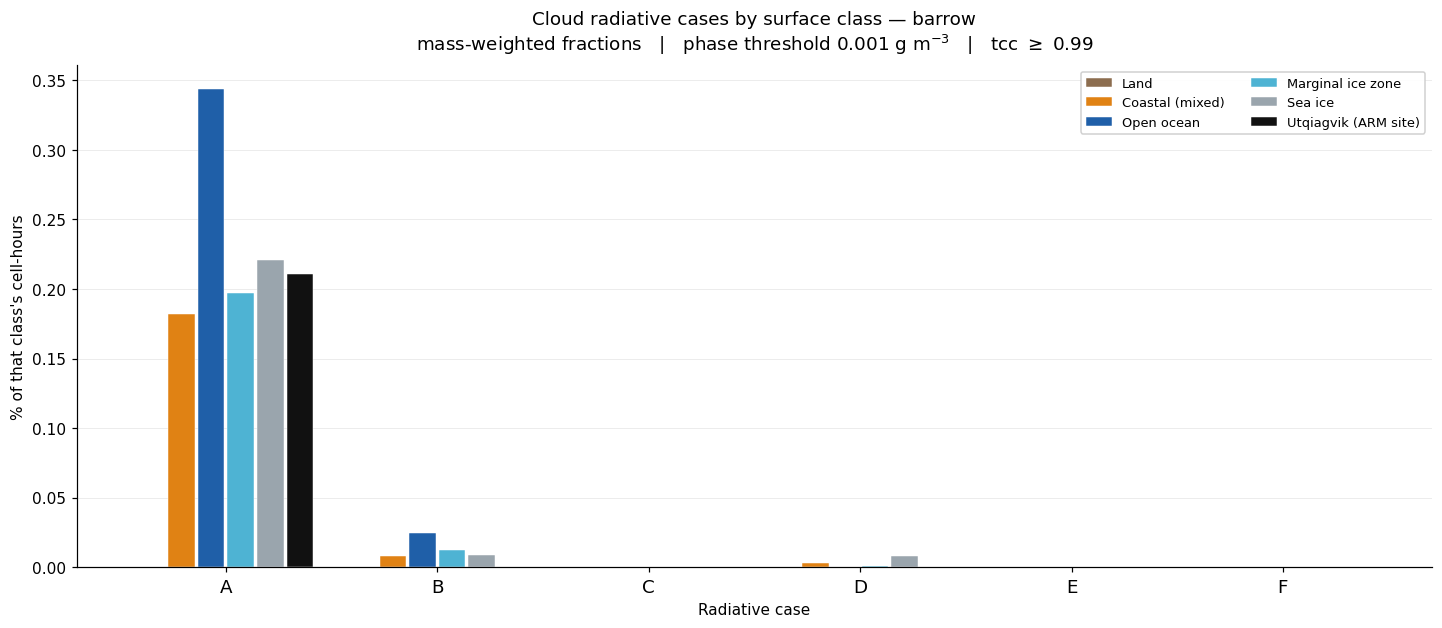

In [15]:
A_abs = ccs.prepare(region="barrow", storage="local", phase_rule="absolute")
ccs.print_report(A_abs)
ccs.fig_case_by_surface(A_abs, out_dir=SAVE_DIR);

## The level-count basis, for comparison

Worth running once. This is Rachel's arithmetic applied literally at 23 levels;
the collapse of cases B, C and F is the reason the mass basis is the default.

Cloud cases A-F by surface class
  Pressure   : 117 file(s) from /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow_pressure
  Basis      : levels-weighted phase fractions
  Phase thr  : 0.001 g m-3   rule: fraction
  Cloudy when: tcc >= 0.99
  Single lvl : 26 of 654 file(s) overlap the pressure dates
  Loaded single-level subset: 5,592 time steps
  Workers    : 10
    [10/117] done
    [20/117] done
    [30/117] done
    [40/117] done
    [50/117] done
    [60/117] done
    [70/117] done
    [80/117] done
    [90/117] done
    [100/117] done
    [110/117] done
    [117/117] done

------------------------------------------------------------------------------
  FILTER BREAKDOWN (fraction of all cell-hours, each filter alone)
------------------------------------------------------------------------------
    Total cloud cover >= threshold        61.4%
    Has liquid in the column              43.4%
    Clear sky below cloud base           100.0%  

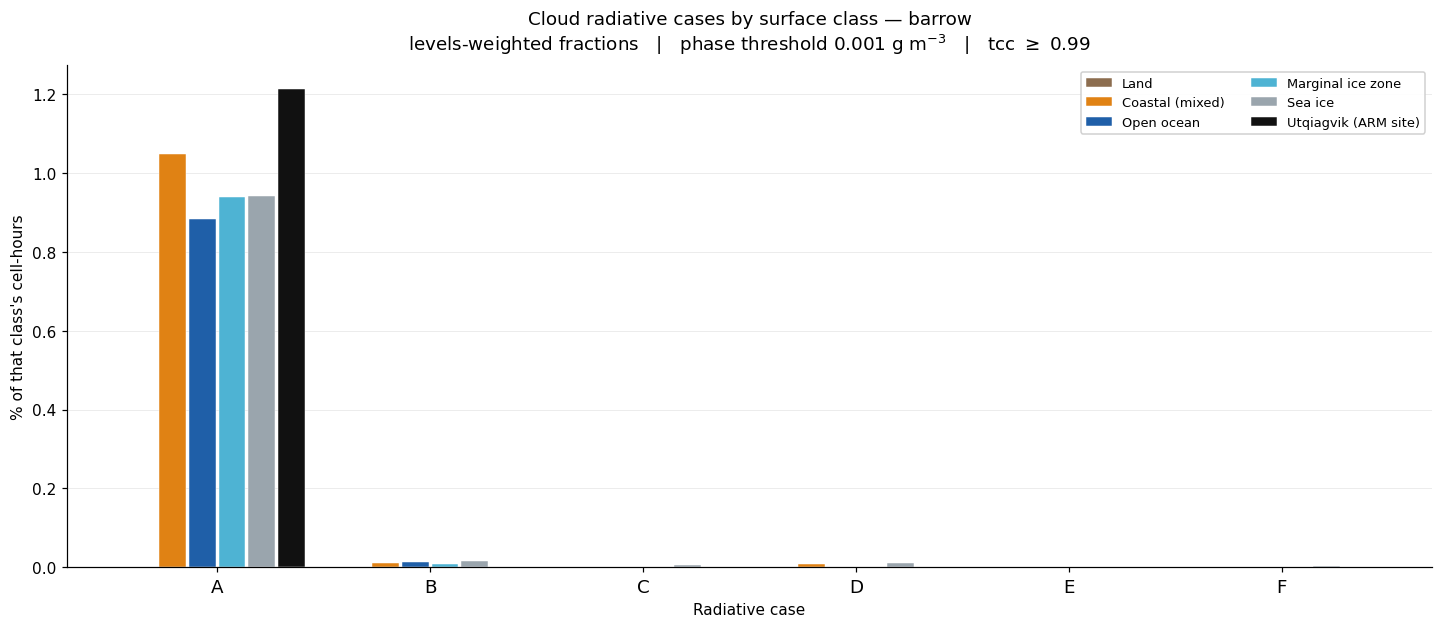

In [16]:
A_levels = ccs.prepare(region="barrow", storage="local", basis="levels")
ccs.print_report(A_levels)
ccs.fig_case_by_surface(A_levels, out_dir=SAVE_DIR);

## Comparing against Rachel's observed statistics

Her summary table was mentioned but not attached to this session, so the
comparison below is a placeholder — fill `OBSERVED` in with the "Hours passing
column filters" column (as a percent of her total dataset hours) and re-run.

Two rules for the comparison to be fair:

- use her **raw** column, not the ≥30 min one (see difference 3 above);
- compare her site against **the ARM cell**, not the domain average — the
  domain mixes open ocean, marginal ice and pack ice, which have visibly
  different case frequencies in figure 1.

In [17]:
import numpy as np
from cloud_vertical_cases import CASE_LABELS, CASE_ORDER

# Rachel's "% of dataset, hours passing column filters", per case.
OBSERVED = {"A": None, "B": None, "C": None, "D": None, "E": None, "F": None}

era5_site = ccs.case_percent(A, A.site_code)
era5_dom = ccs.case_percent(A)
print(f"{'case':<6}{'ERA5 ARM cell':>16}{'ERA5 domain':>14}{'ARM observed':>15}")
for c in CASE_ORDER:
    lab = CASE_LABELS[c]
    obs = OBSERVED.get(lab)
    obs_s = f"{obs:.3f}%" if obs is not None else "(not supplied)"
    print(f"{lab:<6}{era5_site[c]:>15.3f}%{era5_dom[c]:>13.3f}%{obs_s:>15}")

case     ERA5 ARM cell   ERA5 domain   ARM observed
A               1.031%        1.501% (not supplied)
B               0.000%        0.011% (not supplied)
C               0.000%        0.001% (not supplied)
D               0.000%        0.014% (not supplied)
E               0.000%        0.000% (not supplied)
F               0.000%        0.000% (not supplied)


## Threshold sensitivity

Everything here depends on `phase_threshold`, and the snow filter especially so.
Re-running `prepare` at a few values is the honest way to show it — each call
re-streams the archive, so this cell is slow.

In [18]:
for thr in (1e-3, 1e-2, 5e-2):
    Ai = ccs.prepare(region="barrow", storage="local", phase_threshold=thr)
    pct = ccs.case_percent(Ai)
    tot = pct[CASE_ORDER].sum()
    snow = 100 * Ai.filt_pass["no_snow"] / Ai.filt_total
    print(f"threshold {thr:>7g} g/m3 : no-snow filter passes {snow:5.1f}%, "
          f"total cases {tot:6.3f}%")

Cloud cases A-F by surface class
  Pressure   : 117 file(s) from /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow_pressure
  Basis      : mass-weighted phase fractions
  Phase thr  : 0.001 g m-3   rule: fraction
  Cloudy when: tcc >= 0.99
  Single lvl : 26 of 654 file(s) overlap the pressure dates
  Loaded single-level subset: 5,592 time steps
  Workers    : 10
    [10/117] done
    [20/117] done
    [30/117] done
    [40/117] done
    [50/117] done
    [60/117] done
    [70/117] done
    [80/117] done
    [90/117] done
    [100/117] done
    [110/117] done
    [117/117] done
threshold   0.001 g/m3 : no-snow filter passes  38.6%, total cases  1.603%
Cloud cases A-F by surface class
  Pressure   : 117 file(s) from /Users/andrewbuggee/Documents/VS_CODE/Python-Research/ERA5/surface_energy_budget/data/barrow_pressure
  Basis      : mass-weighted phase fractions
  Phase thr  : 0.01 g m-3   rule: fraction
  Cloudy when: tcc >= 0.99
  Single lvl : 2